# Random Forest - Model Development Workflow

> **MLCourse · Machine Learning · supervised · classification**

Production workflow on REAL breast-cancer data: baseline forest → OOB
validation → n_estimators/max_features tuning → importances vs permutation
importances (and why they differ).

## What you'll learn
- One-liner strong baseline (`oob_score=True`)
- Reading the OOB curve as trees accumulate
- Grid-search that actually matters (few knobs)
- Honest importance measurement via `permutation_importance`

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

cancer = load_breast_cancer(as_frame=True)
X, y = cancer.data, cancer.target            # 0=malignant, 1=benign

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.25,
                                          random_state=42, stratify=y)

## 1. Strong baseline + free OOB validation

In [2]:
rf = RandomForestClassifier(n_estimators=400, oob_score=True,
                            n_jobs=-1, random_state=42).fit(X_tr, y_tr)

print(f"train acc : {rf.score(X_tr, y_tr):.4f}")
print(f"OOB acc   : {rf.oob_score_:.4f}   ← from the 37% holdouts, no extra split!")
print(f"test acc  : {rf.score(X_te, y_te):.4f}")

pd.DataFrame(confusion_matrix(y_te, rf.predict(X_te)),
             index=["true malignant", "true benign"],
             columns=["pred malignant", "pred benign"])

train acc : 1.0000
OOB acc   : 0.9624   ← from the 37% holdouts, no extra split!
test acc  : 0.9580


,pred malignant,pred benign
true malignant,49,4
true benign,2,88


## 2. OOB error curve - how many trees are enough?

In [3]:
curve = []
for k in [10, 50, 100, 200, 400]:
    m = RandomForestClassifier(n_estimators=k, oob_score=True,
                               n_jobs=-1, random_state=42).fit(X_tr, y_tr)
    curve.append({"trees": k, "oob": round(m.oob_score_, 4),
                  "test": round(m.score(X_te, y_te), 4)})
display(pd.DataFrame(curve))
print("accuracy plateaus early; more trees tighten probability estimates only.")

D:\projects\python\MLCourse\.venv\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


,trees,oob,test
0,10,0.9484,0.951
1,50,0.9601,0.951
2,100,0.9624,0.958
3,200,0.9624,0.958
4,400,0.9624,0.958


accuracy plateaus early; more trees tighten probability estimates only.


## 3. The small grid that matters

In [4]:
grid = GridSearchCV(
    RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42),
    {"max_features": ["sqrt", 0.3, 0.5],
     "min_samples_leaf": [1, 2, 5],
     "class_weight": [None, "balanced"]},
    cv=5, n_jobs=-1)
grid.fit(X_tr, y_tr)
best = grid.best_estimator_
print("best:", grid.best_params_)
print(f"CV {grid.best_score_:.4f} | test {best.score(X_te, y_te):.4f}")

best: {'class_weight': None, 'max_features': 'sqrt', 'min_samples_leaf': 1}
CV 0.9624 | test 0.9580


## 4. Importances done right - impurity vs permutation

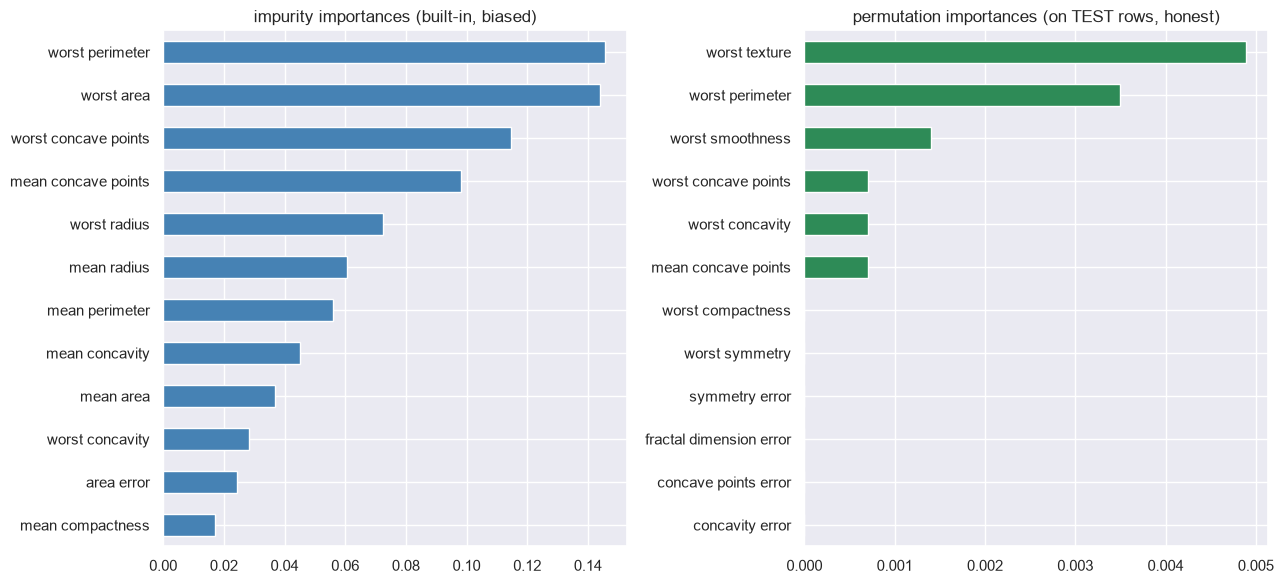

,perm_drop_in_acc
worst texture,0.0049
worst perimeter,0.0035
worst smoothness,0.0014
mean concave points,0.0007
worst concavity,0.0007


In [5]:
impurity_imp = pd.Series(best.feature_importances_,
                         index=X.columns).sort_values()
perm = permutation_importance(best, X_te, y_te, n_repeats=10, random_state=42)
perm_imp = pd.Series(perm.importances_mean, index=X.columns).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
impurity_imp.tail(12).plot(kind="barh", color="steelblue", ax=axes[0])
axes[0].set_title("impurity importances (built-in, biased)")
perm_imp.tail(12).plot(kind="barh", color="seagreen", ax=axes[1])
axes[1].set_title("permutation importances (on TEST rows, honest)")
plt.tight_layout(); plt.show()

top5 = perm_imp.nlargest(5).round(4)
display(top5.to_frame("perm_drop_in_acc"))

## Summary & key takeaways

- RF baseline is nearly knob-free: scale NOT required, `sqrt` max_features,
  300-500 trees, `oob_score=True` for instant validation.
- Only max_features/min_samples_leaf/class_weight meaningfully move results.
- Impurity importances flatter continuous features; permutation importances
  measure REAL predictive contribution on held-out patients.
- Errors concentrate exactly like any classifier - read the confusion matrix.